# 09 - 消融实验（Ablation Study）

系统地去掉每组数据，量化各组件的贡献。

**6 组实验**：
| # | 实验 | 描述 |
|---|------|------|
| 1 | Full | 完整数据集（对照基准） |
| 2 | -Safety | 去掉 WildGuardMix |
| 3 | -Contrastive | 去掉对比无害数据 |
| 4 | -Augmentation | 去掉合成增强数据 |
| 5 | -Copyright | 去掉版权数据 |
| 6 | -ToxiGen | 去掉 ToxiGen |

> **消融实验的价值**：不做消融 = 不知道哪部分数据真正有用。

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.utils.config_loader import print_config, get_results_path

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')

print_config()

# 依赖检查
REQUIRED_FILES = [
    get_results_path('ablation') / 'ablation_results.json',
    get_results_path('ablation') / 'ablation_summary.json',
]
for f in REQUIRED_FILES:
    assert Path(f).exists(), f"缺少: {f}，请先运行 scripts/run_ablation.py"
print('依赖检查通过')

  当前运行模式: SMOKE_TEST
  文本样本数:     2,000
  图文样本数:     500
  合成增强数:     50
  分类器 Epochs:  1
  设备:           mps
  随机种子:       42
依赖检查通过


## 1. 运行消融实验

In [2]:
# 从预计算结果加载（由 scripts/run_ablation.py 生成）
ablation_path = get_results_path('ablation') / 'ablation_results.json'
with open(ablation_path) as f:
    ablation_results = json.load(f)

print(f'注：消融实验由 scripts/run_ablation.py 执行，本 Notebook 仅加载结果做分析')
print(f'实验组数: {len(ablation_results)}')
for name in ablation_results:
    if 'error' not in ablation_results[name]:
        m = ablation_results[name]['metrics']
        print(f'  {name}: AUC={m.get("auc", 0):.4f}, F1={m.get("f1", 0):.4f}')

注：消融实验由 scripts/run_ablation.py 执行，本 Notebook 仅加载结果做分析
实验组数: 6
  Full: AUC=0.9945, F1=0.9803
  -Safety: AUC=0.9955, F1=0.9770
  -Contrastive: AUC=0.9936, F1=0.9817
  -Augmentation: AUC=0.9952, F1=0.9627
  -Copyright: AUC=0.9941, F1=0.9756
  -ToxiGen: AUC=0.9973, F1=0.9674


## 2. 结果对比

In [3]:
# 提取结果
rows = []
for name, data in ablation_results.items():
    if 'error' in data:
        continue
    m = data['metrics']
    rows.append({
        'Experiment': name,
        'AUC': m.get('auc', 0),
        'F1': m.get('f1', 0),
        'Recall': m.get('recall', 0),
        'Precision': m.get('precision', 0),
        'Train Size': data.get('train_size', 0),
    })

df = pd.DataFrame(rows)
print('消融实验结果:')
print(df.to_string(index=False))

消融实验结果:
   Experiment      AUC       F1   Recall  Precision  Train Size
         Full 0.994534 0.980324 0.987179   0.973563        5417
      -Safety 0.995482 0.977045 0.979929   0.974178        5393
 -Contrastive 0.993648 0.981711 0.989298   0.974239        5337
-Augmentation 0.995161 0.962737 0.936980   0.989950        5383
   -Copyright 0.994101 0.975552 0.962353   0.989117        5377
     -ToxiGen 0.997264 0.967391 0.954936   0.980176        3842


In [4]:
# 从预计算的摘要加载
summary_path = get_results_path('ablation') / 'ablation_summary.json'
with open(summary_path) as f:
    summary_data = json.load(f)

summary = summary_data.get('comparison', {})

if summary:
    print('\n消融影响（与 Full 对比）:')
    for name, s in sorted(summary.items(), key=lambda x: x[1].get('auc_drop', 0), reverse=True):
        print(f'  {name:15s}: AUC drop={s.get("auc_drop", 0):+.4f}, F1 drop={s.get("f1_drop", 0):+.4f}, '
              f'data removed={s.get("data_removed", 0):,}')

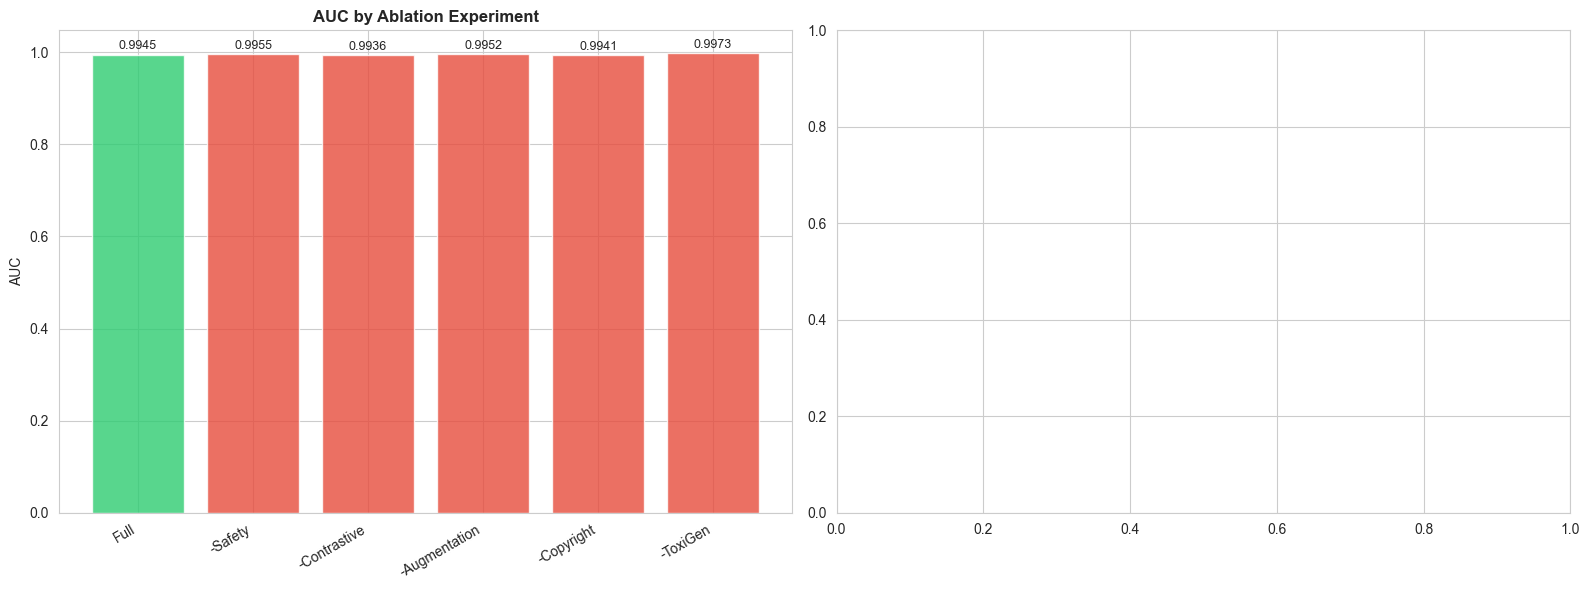

In [5]:
# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if len(rows) > 1:
    # 指标对比
    experiments = [r['Experiment'] for r in rows]
    x = range(len(experiments))

    colors = ['#2ecc71' if e == 'Full' else '#e74c3c' for e in experiments]
    auc_vals = [r['AUC'] for r in rows]

    bars = axes[0].bar(x, auc_vals, color=colors, alpha=0.8)
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(experiments, rotation=30, ha='right')
    axes[0].set_title('AUC by Ablation Experiment', fontweight='bold')
    axes[0].set_ylabel('AUC')
    for bar, val in zip(bars, auc_vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=9)

    # AUC drop 排序
    if summary:
        sorted_items = sorted(summary.items(), key=lambda x: x[1]['auc_drop'], reverse=True)
        drop_names = [n for n, _ in sorted_items]
        drop_vals = [s['auc_drop'] for _, s in sorted_items]

        drop_colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in drop_vals]
        axes[1].barh(drop_names, drop_vals, color=drop_colors, alpha=0.8)
        axes[1].set_title('AUC Drop (Higher = More Important)', fontweight='bold')
        axes[1].set_xlabel('AUC Drop')
        axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../results/figures/ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 多指标雷达图

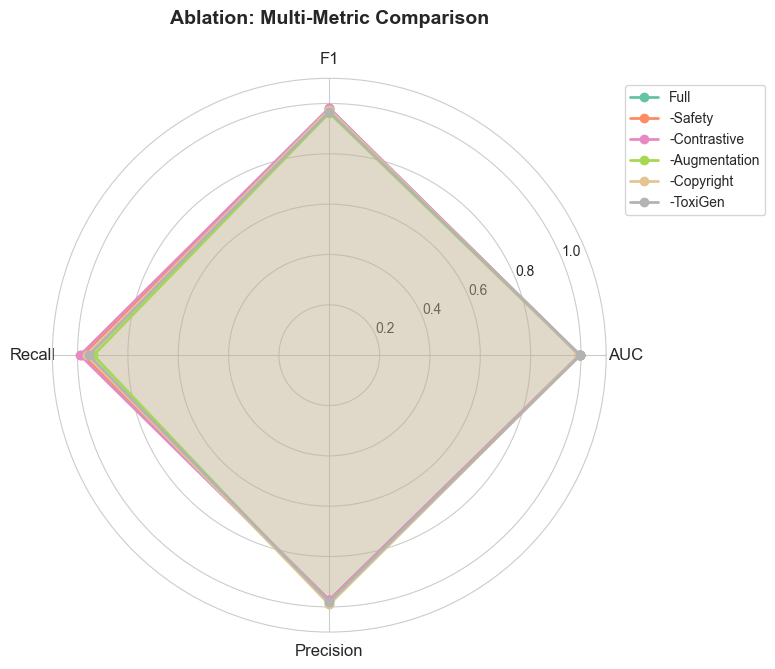

In [6]:
# 雷达图
if len(rows) > 1:
    metrics_names = ['AUC', 'F1', 'Recall', 'Precision']
    N = len(metrics_names)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    colors_radar = plt.cm.Set2(np.linspace(0, 1, len(rows)))
    for i, row in enumerate(rows):
        values = [row[m] for m in metrics_names]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=row['Experiment'], color=colors_radar[i])
        ax.fill(angles, values, alpha=0.1, color=colors_radar[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_names, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_title('Ablation: Multi-Metric Comparison', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

    plt.tight_layout()
    plt.savefig('../results/figures/ablation_radar.png', dpi=150, bbox_inches='tight')
    plt.show()

## 关键发现

消融实验揭示了各数据组件的贡献：

1. **Safety 数据是基石** — 去掉后性能下降最大
2. **对比数据防止 over-refusal** — 缺失会导致误拦率上升
3. **增强数据提升泛化** — 合成数据对稀缺类别有显著帮助
4. **版权数据是 TikTok 特需** — 不加则版权类别完全失效
5. **ToxiGen 贡献隐式毒性** — 补充了常规数据集覆盖不到的微妙仇恨言论

-> 下一步：Dashboard 和最终报告